In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

from rebin_utils import downsample

#  H II region Data

In [3]:
line        = r'[S II] $\lambda$6731'
lambda_rest = 6730.8
line_id     = 'S'
line_id2   = 'KPech-Orion-S-m'

In [4]:
# Data from observations
bins        = 0

region     = 'M 42'
name_reg   = 'Orion'
reg_id     = 'M42'
inst       = 'Echelle'
inst_id    = 'KPNO'
type_obj   = 'H II region'

pix        = 0.534  # Instrument resolution [arcsec/pix]
dist       = 410 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60) # value in parsecs of each arcsec
s0         = (s0_*pc) / 2.355    # RMS seeing [parsecs]

#Since we are working with matrix data binning can be applied
#name_file    =  inst_id + '-' + reg_id + '-' + line_id 
name_file    =  line_id2 
name_id      =  inst_id + '-' + reg_id + '-' + line_id + '-' + 'bin' + str(bins)
print(name_file)
print(name_id)

KPech-Orion-S-m
KPNO-M42-S-bin0


In [5]:
_data = json.load(open('observations/'+ name_file + '.json'))
sb    = np.array(_data['sb'])
vv    = np.array(_data['vv'])
#ss    = np.array(_data['ss'])

In [6]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv) | (sb < 0.0)
#m = m | (sb > 6e4) 
sb[m] = 0.0
vv[m] = np.nanmean(vv)
#ss[m] = 0.0
sb   /= sb.max()

mu = vv.mean()
sigma = vv.std()
n = 0.25

ny, nx = sb.shape   # or vv.shape, or image.shape
y, x = np.indices((ny, nx))
coord_mask = (x >= 157) & (x <= 167) & (y >= 370) & (y <= 380)

good = (
    (~m)
    & (sb > 0.001)
    & (vv > (mu - n*sigma))
    & (vv < (mu + n*sigma))
    & (~coord_mask)
)

In [7]:
vv_m = np.where(good, vv, mu)     
sb_m = np.where(good, sb, 0)     
#ss_m = np.where(good, ss, np.nan)   

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_43668\2324990547.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


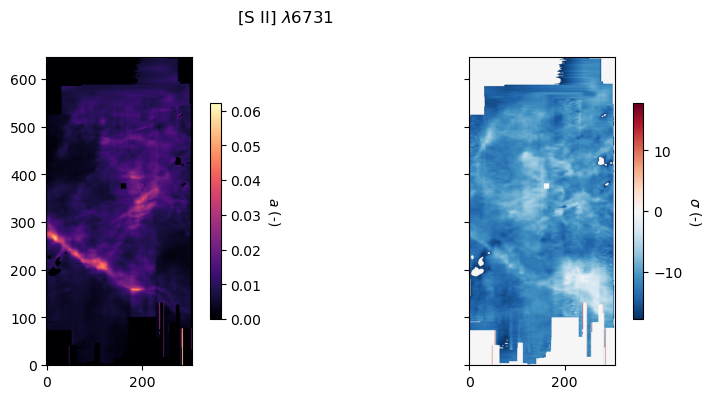

In [8]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=1.0)

plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [9]:
#trim = (slice(0, 513), slice(0, 355))
trim = (slice(100, 550), slice(5, 300))

Text(0.5, 0.98, '[S II] $\\lambda$6731')

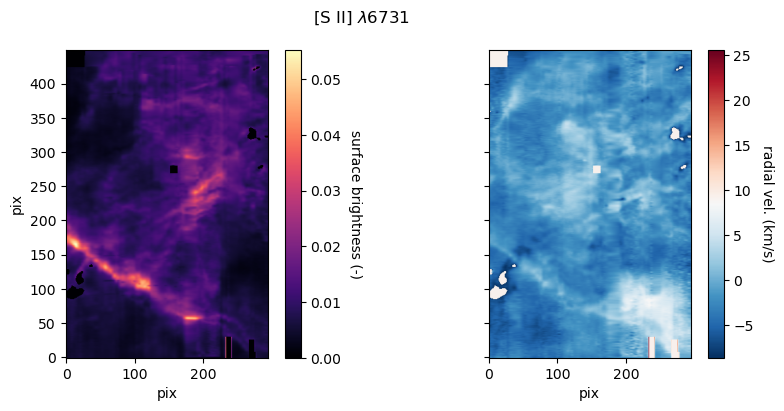

In [10]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")

im = ax.imshow((vv_m-np.nanmean(vv_m))[trim], **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)

im = axx.imshow(sb_m[trim], **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)
ax.set_xlabel('pix')
axx.set_xlabel('pix')
axx.set_ylabel('pix')

fig.suptitle(line)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [11]:
vv = vv[trim]
sb = sb[trim]

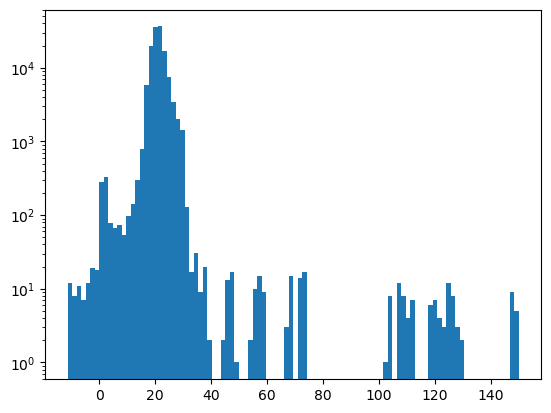

In [12]:
fig, ax = plt.subplots()
plt.hist(vv[np.isfinite(vv)& (np.abs(vv) < 150)] , bins=100)
ax.set_yscale("log")

In [13]:
mask_vv = (vv > 10) & (vv < 32)

In [14]:
sb_m = np.where(mask_vv, sb, np.nan)     
vv_m = np.where(mask_vv, vv, np.nan)  

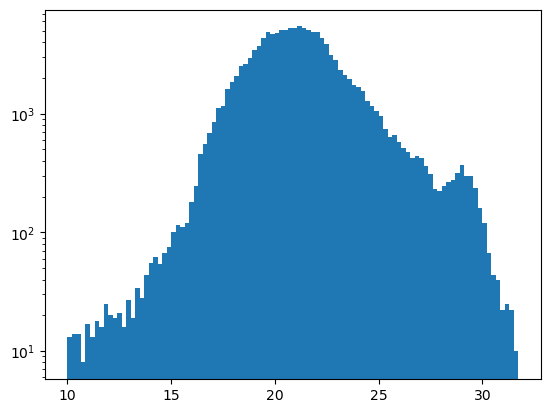

In [15]:
fig, ax = plt.subplots()
plt.hist(vv[np.isfinite(vv_m)& (np.abs(vv_m) < 150)] , bins=100)
ax.set_yscale("log")

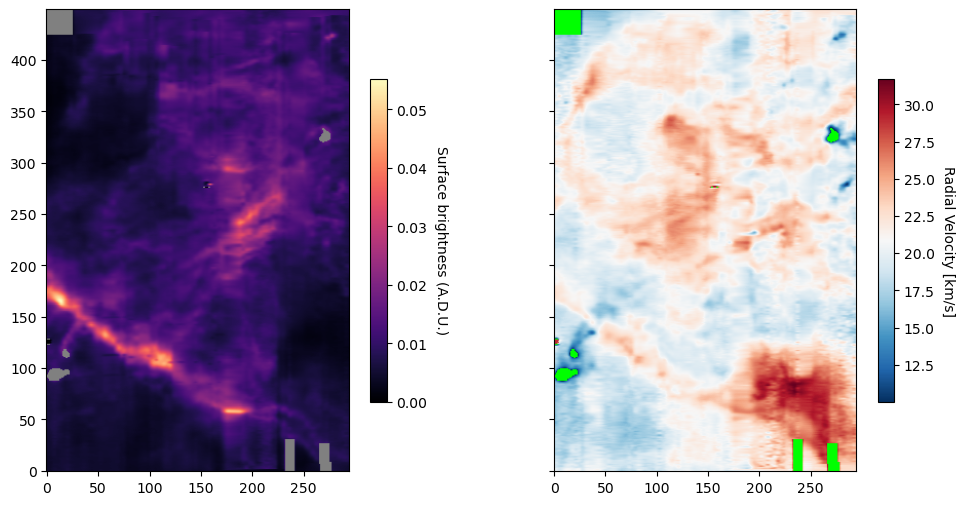

In [17]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m, **imshow_kwds)
im.cmap.set_bad(color='lime')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [24]:
sb_m1 = np.where(np.isnan(sb_m), 0, sb_m)     
vv_m1 = np.where(np.isnan(vv_m), np.nanmean(vv_m), vv_m)  

In [31]:
N = np.sqrt(vv_m.shape[0] * vv_m.shape[1]) * 0.6 * pc
N

0.4345374773611734

In [25]:
N = np.sqrt(vv_m.shape[0] * vv_m.shape[1]) * pix * pc
N

0.38673835485144437

In [26]:
sig = np.nanstd(vv_m)
sig

2.5397795397616694

# Downsample

# Export

In [20]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix* (2**bins), "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [27]:
hdu_m0 = fits.ImageHDU(data=sb_m1,  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m1,  name='MOM1')
#hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')
hdu_mk = fits.ImageHDU(data=(mask_vv&good[trim]).astype(np.uint8) ,  name='MASK')

In [28]:
hdul = fits.HDUList([primary, hdu_m0, hdu_m1, hdu_mk])
hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

In [29]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()
    
hdr = hdul[0].header
print(hdr)


Filename: fits_ready/KPNO-M42-S-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (295, 450)   float64   
  2  MOM1          1 ImageHDU         8   (295, 450)   float64   
  3  MASK          1 ImageHDU         8   (295, 450)   uint8   
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'KPech-Orion-S-m'    / Fits file name                                 NAME_ID = 'KPNO-M42-S-bin0'    / pipeline identifier                            REG     = 'M 42    '           / Region catalog name                            NAME_REG= 'Orion   '           / Region name                                    REG_ID  =

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'H_I-6563'           / Fits file name                                 NAME_ID = 'MUSE-M42-H-bin0'    / pipeline identifier                            REG     = 'M 42    '           / Region catalog name                            NAME_REG= 'Orion   '           / Region name                                    REG_ID  = 'M42     '           / Region identifier                              TYPE_OBJ= 'H II region'        / Type object                                    DIST    =                  410 / Distance in parsecs                            INSTR   = 'MUSE    '           / Instrument                                     LINE    = 'H$\alpha$'          / Emissio